# Exercise 2
**Cristina Correa - 1819211867**


Add more dense layers to the model, and experiment with
different layer sizes (e.g., 64, 128 units). How does this impact the model's
performance?

In [16]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from keras import layers, Model
from keras.callbacks import EarlyStopping

# Ensure TensorFlow backend
os.environ["KERAS_BACKEND"] = "tensorflow"

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

dataframe.shape

# Here's a preview of a few samples:
dataframe.head()

# Let's split the data into a training and validation set:
val_dataframe = dataframe.sample(frac=0.2, random_state=1337)
train_dataframe = dataframe.drop(val_dataframe.index)
print(
    f"Using {len(train_dataframe)} samples for training "
    f"and {len(val_dataframe)} for validation"
)


# Convert dataframes to tf.data.Datasets
def dataframe_to_dataset(dataframe, target="target"):
    dataframe = dataframe.copy()
    labels = dataframe.pop(target)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe)).batch(32)
    return ds


# Let's generate `tf.data.Dataset` objects for each dataframe:
train_ds = dataframe_to_dataset(train_dataframe)
val_ds = dataframe_to_dataset(val_dataframe)


# Preprocessing layers for numerical and categorical features
def encode_feature(feature, name, dataset, is_string=False):
    lookup_class = layers.StringLookup if is_string else layers.IntegerLookup
    lookup = lookup_class(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name]).map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    return lookup(feature)


def normalize_feature(feature, name, dataset):
    normalizer = layers.Normalization()
    feature_ds = dataset.map(lambda x, y: tf.expand_dims(x[name], -1))
    normalizer.adapt(feature_ds)
    return normalizer(feature)


inputs = {
    "age": layers.Input(name="age", shape=(1,), dtype="float32"),
    "sex": layers.Input(name="sex", shape=(1,), dtype="int64"),
    "cp": layers.Input(name="cp", shape=(1,), dtype="int64"),
    "trestbps": layers.Input(name="trestbps", shape=(1,), dtype="float32"),
    "chol": layers.Input(name="chol", shape=(1,), dtype="float32"),
    "fbs": layers.Input(name="fbs", shape=(1,), dtype="int64"),
    "restecg": layers.Input(name="restecg", shape=(1,), dtype="int64"),
    "thalach": layers.Input(name="thalach", shape=(1,), dtype="float32"),
    "exang": layers.Input(name="exang", shape=(1,), dtype="int64"),
    "oldpeak": layers.Input(name="oldpeak", shape=(1,), dtype="float32"),
    "slope": layers.Input(name="slope", shape=(1,), dtype="int64"),
    "ca": layers.Input(name="ca", shape=(1,), dtype="int64"),
    "thal": layers.Input(name="thal", shape=(1,), dtype="string"),
}

# Encoded features
encoded_features = [
    encode_feature(inputs["sex"], "sex", train_ds),
    encode_feature(inputs["cp"], "cp", train_ds),
    encode_feature(inputs["fbs"], "fbs", train_ds),
    encode_feature(inputs["restecg"], "restecg", train_ds),
    encode_feature(inputs["exang"], "exang", train_ds),
    encode_feature(inputs["ca"], "ca", train_ds),
    encode_feature(inputs["thal"], "thal", train_ds, is_string=True),
    normalize_feature(inputs["age"], "age", train_ds),
    normalize_feature(inputs["trestbps"], "trestbps", train_ds),
    normalize_feature(inputs["chol"], "chol", train_ds),
    normalize_feature(inputs["thalach"], "thalach", train_ds),
    normalize_feature(inputs["oldpeak"], "oldpeak", train_ds),
    normalize_feature(inputs["slope"], "slope", train_ds),
]

Using 242 samples for training and 61 for validation


# Experiment a thin first layer

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5670 - loss: 0.6859 - val_accuracy: 0.7705 - val_loss: 0.6523
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7515 - loss: 0.6486 - val_accuracy: 0.7705 - val_loss: 0.6152
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7024 - loss: 0.6214 - val_accuracy: 0.7705 - val_loss: 0.5792
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7281 - loss: 0.5876 - val_accuracy: 0.7705 - val_loss: 0.5392
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7160 - loss: 0.5582 - val_accuracy: 0.7705 - val_loss: 0.4992
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7108 - loss: 0.5224 - val_accuracy: 0.7705 - val_loss: 0.4633
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7030 - loss: 0.5031 - val_accuracy: 0.7705 - val_loss: 0.4335
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7405 - loss: 0.4477 - val_accuracy: 0.7705 - val_loss: 0.4097
Epoch 

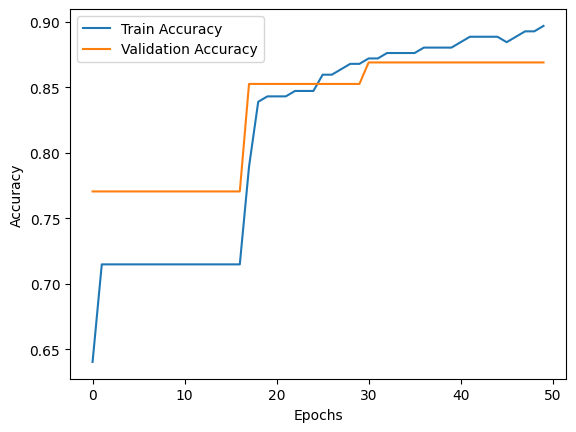

In [21]:
# Build the model
def build_model():
    # Concatenate all features and define the model layers
    all_features = layers.concatenate(encoded_features)

    # Adding more dense layers with different sizes
    x = layers.Dense(1, activation="relu")(all_features)  
    x = layers.Dense(64, activation="relu")(x)  
    x = layers.Dense(32, activation="relu")(x)  
    output = layers.Dense(1, activation="sigmoid")(x)  

    # Compile the model
    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


model = build_model()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

# Plot training history
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

If I add a very thin first layer, the accuracy with less than 10 Epoch is very low compared with the accuracy with +30 epoch. 

In [22]:
# Inference on a new sample
sample = {
    "age": 60,
    "sex": 1,
    "cp": 1,
    "trestbps": 145,
    "chol": 233,
    "fbs": 1,
    "restecg": 2,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 2.3,
    "slope": 3,
    "ca": 0,
    "thal": "fixed",
}

input_dict = {name: tf.convert_to_tensor([value]) for name, value in sample.items()}
predictions = model.predict(input_dict)

print(
    f"This patient has a {100 * predictions[0][0]:.1f}% probability of heart disease."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
This patient has a 17.2% probability of heart disease.


--------------
# Experiment with two first thick layers

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6257 - loss: 0.6565 - val_accuracy: 0.7705 - val_loss: 0.5096
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7538 - loss: 0.4941 - val_accuracy: 0.7869 - val_loss: 0.4024
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8104 - loss: 0.3968 - val_accuracy: 0.8197 - val_loss: 0.3585
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8576 - loss: 0.3186 - val_accuracy: 0.8197 - val_loss: 0.3496
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8586 - loss: 0.2996 - val_accuracy: 0.8197 - val_loss: 0.3574
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.2888 - val_accuracy: 0.8197 - val_loss: 0.3706
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9117 - loss: 0.2323 - val_accuracy: 0.8197 - val_loss: 0.3799
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9030 - loss: 0.2448 - val_accuracy: 0.8197 - val_loss: 0.3806
Epoch 

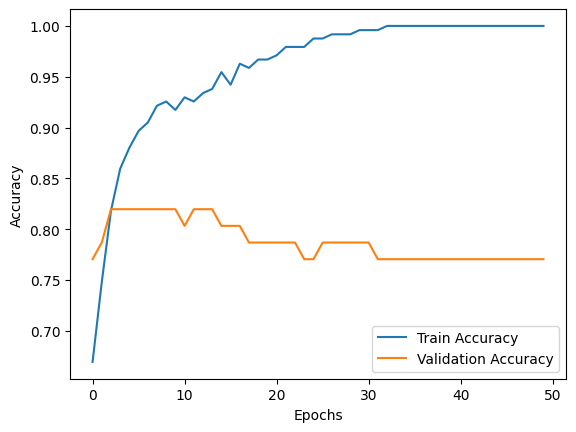

In [23]:
# Build the model
def build_model():
    # Concatenate all features and define the model layers
    all_features = layers.concatenate(encoded_features)

    # Adding more dense layers with different sizes
    x = layers.Dense(128, activation="relu")(all_features)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    # Compile the model
    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


model = build_model()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

# Plot training history
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

With two thick layers, we'll have a more exponential train accuracy when it comes to the number of epochs

In [24]:
# Inference on a new sample
sample = {
    "age": 60,
    "sex": 1,
    "cp": 1,
    "trestbps": 145,
    "chol": 233,
    "fbs": 1,
    "restecg": 2,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 2.3,
    "slope": 3,
    "ca": 0,
    "thal": "fixed",
}

input_dict = {name: tf.convert_to_tensor([value]) for name, value in sample.items()}
predictions = model.predict(input_dict)

print(
    f"This patient has a {100 * predictions[0][0]:.1f}% probability of heart disease."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
This patient has a 0.0% probability of heart disease.


--------
# Experiment with three different layouts

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.6477 - loss: 0.6627 - val_accuracy: 0.7705 - val_loss: 0.5683
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7233 - loss: 0.5519 - val_accuracy: 0.7541 - val_loss: 0.4706
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7857 - loss: 0.4398 - val_accuracy: 0.8033 - val_loss: 0.4032
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8488 - loss: 0.3793 - val_accuracy: 0.8361 - val_loss: 0.3727
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8664 - loss: 0.3494 - val_accuracy: 0.8197 - val_loss: 0.3696
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8831 - loss: 0.2739 - val_accuracy: 0.8361 - val_loss: 0.3853
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8801 - loss: 0.2771 - val_accuracy: 0.7869 - val_loss: 0.3963
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9037 - loss: 0.2364 - val_accuracy: 0.7869 - val_loss: 0.4053
Epoch 9

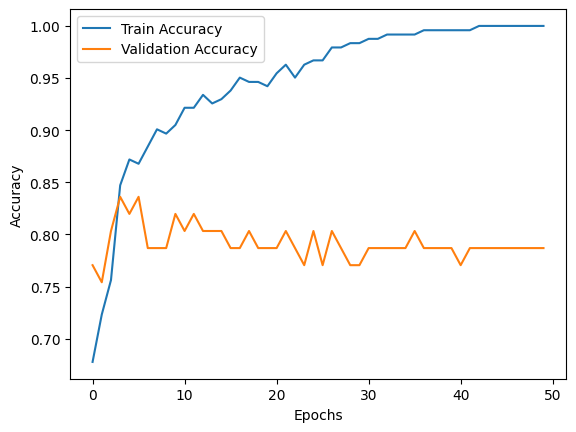

In [26]:
# Build the model
def build_model():
    # Concatenate all features and define the model layers
    all_features = layers.concatenate(encoded_features)

    # Adding more dense layers with different sizes
    x = layers.Dense(128, activation="relu")(all_features)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    # Compile the model
    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


model = build_model()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

# Plot training history
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

We can see that the train accuracy is almost the same as the second experiment but the validation accuracy is slightly better

In [27]:
# Inference on a new sample
sample = {
    "age": 60,
    "sex": 1,
    "cp": 1,
    "trestbps": 145,
    "chol": 233,
    "fbs": 1,
    "restecg": 2,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 2.3,
    "slope": 3,
    "ca": 0,
    "thal": "fixed",
}

input_dict = {name: tf.convert_to_tensor([value]) for name, value in sample.items()}
predictions = model.predict(input_dict)

print(
    f"This patient has a {100 * predictions[0][0]:.1f}% probability of heart disease."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
This patient has a 0.0% probability of heart disease.
